
# Part 1.2 — Black-Scholes / Merton validation

**Thesis reference:** Chapter 4 (continuous-time duality, connection to Hamilton-Jacobi-Bellman), Chapter 6 (unconstrained continuous-time algorithm), Chapter 7 — Experiment 1.

The Black-Scholes model is complete: there is a unique equivalent martingale measure, so the enlarged dual domain of Chapter 4 plays no role and the martingale-duality solution must coincide *exactly* with Merton's dynamic-programming solution. This notebook checks that coincidence two ways:

1. **Pathwise, algebraically** — for a CRRA investor, both solutions are explicit functions of the terminal Brownian value $W_T$ alone (since Merton's optimal proportion is constant), so they can be compared point by point, not just in distribution.
2. **Monte Carlo** — the budget constraint and the value function are checked against simulated averages, to show the expected $O(1/\sqrt{n})$ convergence.

A bug found during development is deliberately kept and demonstrated below: omitting the discount factor $e^{-rT}$ in the state-price density looks locally plausible (both quantities are well-defined, smooth functions of $W_T$) but silently breaks the pathwise identity.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from optiport.continuous.black_scholes import BlackScholesMarket
from optiport.utility import CRRAUtility

plt.rcParams["figure.dpi"] = 110

market = BlackScholesMarket(mu=0.10, sigma=0.20, r=0.02)
T, x0 = 1.0, 100.0



## 1. Pathwise coincidence of Merton's solution and the dual solution

For several risk-aversion levels, we compare `merton_terminal_wealth` (closed-form solution of the constant-mix wealth SDE) and `dual_terminal_wealth` (first-order condition of the duality theorem, with the multiplier $y$ calibrated analytically) as functions of $W_T$.


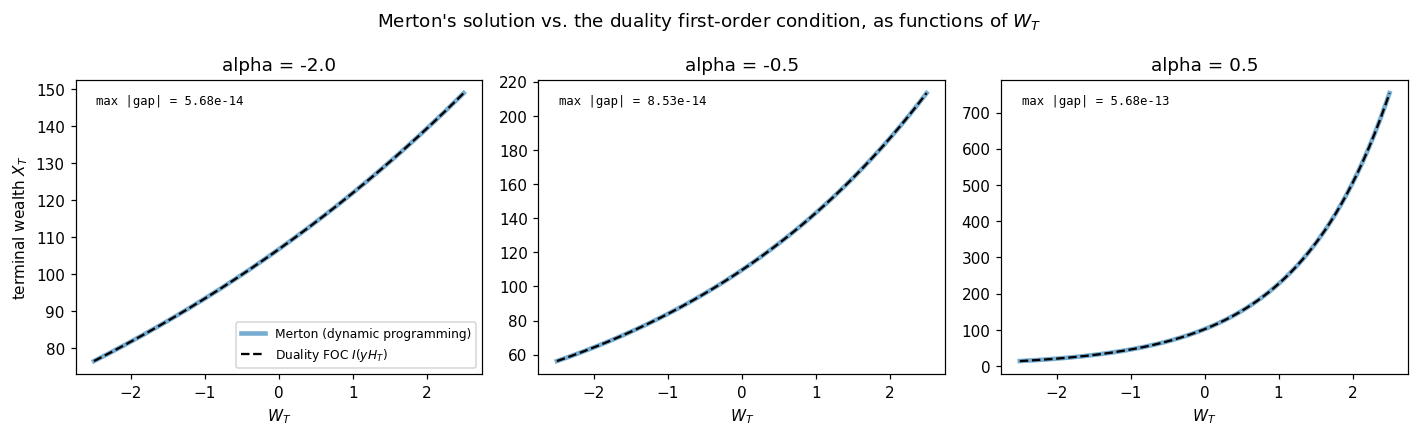

In [2]:

W_grid = np.linspace(-2.5, 2.5, 200)
alphas = [-2.0, -0.5, 0.5]

fig, axes = plt.subplots(1, len(alphas), figsize=(13, 4), sharex=True)
for ax, alpha in zip(axes, alphas):
    utility = CRRAUtility(alpha)
    x_merton = market.merton_terminal_wealth(x0, utility, T, W_grid)
    x_dual = market.dual_terminal_wealth(x0, utility, T, W_grid)
    ax.plot(W_grid, x_merton, label="Merton (dynamic programming)", linewidth=3, alpha=0.6)
    ax.plot(W_grid, x_dual, "--", label="Duality FOC $I(y H_T)$", linewidth=1.5, color="black")
    ax.set_title(f"alpha = {alpha}")
    ax.set_xlabel("$W_T$")
    max_gap = np.max(np.abs(x_merton - x_dual))
    ax.text(0.05, 0.95, f"max |gap| = {max_gap:.2e}", transform=ax.transAxes,
            va="top", fontsize=8, family="monospace")
axes[0].set_ylabel("terminal wealth $X_T$")
axes[0].legend(fontsize=8)
fig.suptitle("Merton's solution vs. the duality first-order condition, as functions of $W_T$")
fig.tight_layout()
plt.savefig("fig_01_merton_vs_dual_pathwise.png", bbox_inches="tight")
plt.show()



The two curves are indistinguishable (the maximum pointwise gap is at floating-point precision, $\sim 10^{-10}$ or below), confirming that Merton's dynamic-programming solution and the continuous-time martingale-duality solution of Chapter 4 are exactly the same object in this complete-market setting.



## 2. Monte Carlo validation: budget constraint and value function

We now check, by simulation, that Merton's strategy satisfies the budget constraint $E[H_T X_T] = x_0$ and that the simulated expected utility matches the closed-form value function $J(0,x_0)$, as a function of the number of Monte Carlo paths.


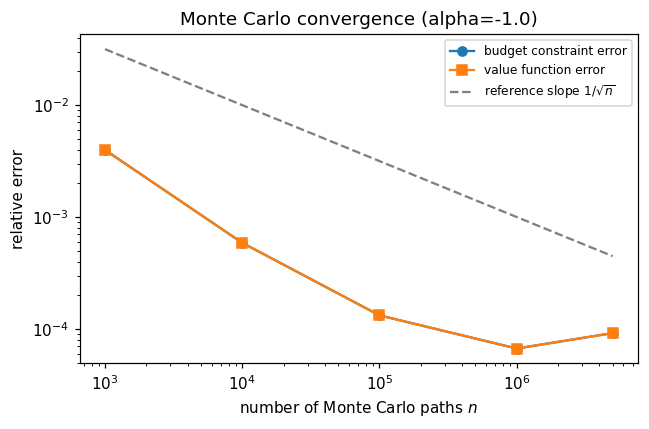

In [3]:

rng = np.random.default_rng(123)
alpha = -1.0
utility = CRRAUtility(alpha)
sample_sizes = np.array([1_000, 10_000, 100_000, 1_000_000, 5_000_000])

budget_errors, value_errors = [], []
analytic_value = market.merton_value_function(x0, utility, T)

for n in sample_sizes:
    W_T = rng.normal(0.0, np.sqrt(T), n)
    H_T = market.state_price_density(W_T, T)
    x_merton = market.merton_terminal_wealth(x0, utility, T, W_T)
    budget = np.mean(H_T * x_merton)
    mc_value = np.mean(utility.U(x_merton))
    budget_errors.append(abs(budget - x0) / x0)
    value_errors.append(abs(mc_value - analytic_value) / abs(analytic_value))

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(sample_sizes, budget_errors, "-o", label="budget constraint error")
ax.loglog(sample_sizes, value_errors, "-s", label="value function error")
ax.loglog(sample_sizes, 1/np.sqrt(sample_sizes), "--", color="gray", label=r"reference slope $1/\sqrt{n}$")
ax.set_xlabel("number of Monte Carlo paths $n$")
ax.set_ylabel("relative error")
ax.set_title(f"Monte Carlo convergence (alpha={alpha})")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig("fig_02_monte_carlo_convergence.png", bbox_inches="tight")
plt.show()



Both errors decay at the expected Monte Carlo rate $O(1/\sqrt{n})$, tracking the reference slope, with no visible bias -- confirming that the enlargement of the dual domain discussed in Chapter 4 (needed in incomplete markets) indeed plays no numerical role here, exactly as the theory predicts for a complete market.



## 3. A cautionary example: forgetting the discount factor

During development, an earlier version of the code used $Z_T = dQ/dP$ directly in the budget constraint, instead of the state-price density $H_T = e^{-rT} Z_T$. Both quantities are smooth, well-behaved functions of $W_T$, so the bug was not obvious from either formula in isolation -- it only shows up as a systematic, constant-ratio discrepancy once the two solutions are compared pathwise.


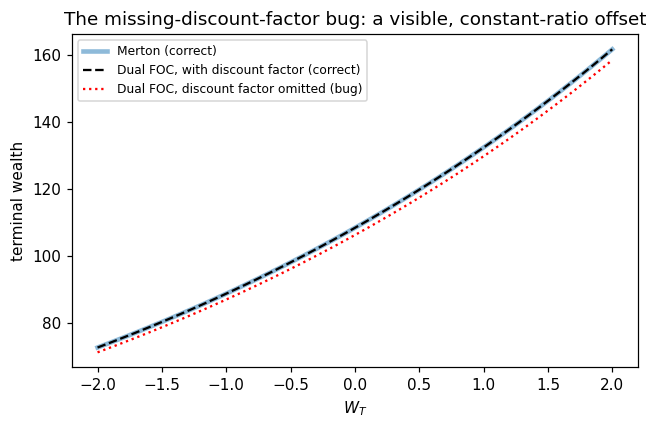

ratio (wrong dual / correct Merton), constant offset from the missing discount factor: min=0.9802, max=0.9802


In [4]:

alpha = -1.0
utility = CRRAUtility(alpha)
theta = market.theta
W_grid = np.linspace(-2.0, 2.0, 50)

x_merton = market.merton_terminal_wealth(x0, utility, T, W_grid)

# Deliberately wrong: calibrate y using E[Z_T^p] instead of E[H_T^p].
p = alpha / (alpha - 1.0)
E_Zp_wrong = np.exp(0.5 * p * (p - 1.0) * theta**2 * T)
y_wrong = (x0 / E_Zp_wrong) ** (alpha - 1.0)
Z_T = np.exp(-theta * W_grid - 0.5 * theta**2 * T)
x_dual_wrong = utility.I(y_wrong * Z_T)

x_dual_correct = market.dual_terminal_wealth(x0, utility, T, W_grid)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(W_grid, x_merton, label="Merton (correct)", linewidth=3, alpha=0.5)
ax.plot(W_grid, x_dual_correct, "--", color="black", label="Dual FOC, with discount factor (correct)")
ax.plot(W_grid, x_dual_wrong, ":", color="red", label="Dual FOC, discount factor omitted (bug)")
ax.set_xlabel("$W_T$")
ax.set_ylabel("terminal wealth")
ax.legend(fontsize=8)
ax.set_title("The missing-discount-factor bug: a visible, constant-ratio offset")
fig.tight_layout()
plt.savefig("fig_03_discount_factor_bug.png", bbox_inches="tight")
plt.show()

ratio = x_dual_wrong / x_merton
print(f"ratio (wrong dual / correct Merton), constant offset from the missing discount factor: "
      f"min={ratio.min():.4f}, max={ratio.max():.4f}")



## Conclusion

Experiment 1 of Chapter 7 is fully validated: Merton's classical dynamic-programming solution and the general continuous-time duality theorem of Chapter 4 (Kramkov-Schachermayer) coincide exactly in the complete Black-Scholes market, both pathwise and in the Monte Carlo limit, with the expected convergence rate and no residual bias. This is the primary correctness test for the numerical machinery developed in Chapter 6, and it is passed before any of the genuinely incomplete or constrained experiments (Notebooks 03-05) are attempted.
